In [2]:
import os
from os.path import expanduser
home = expanduser("~/")

import sys
# sys.path.insert(0, '/global/u2/x/xshuang/gigalens-xh-dev/src')

# import sys
conda_env = sys.path[1]
del sys.path[1]

import os
# sys.path.append(f'{os.environ['HOME']}/gigalens_personal/gigalens/src')
sys.path.append(home+'/gigalens'+'/src')
sys.path.append(conda_env)
sys.path.append(home+'/GIGALens-Code/')
print(sys.path)



srcdir = os.path.join(home, "gigalens/src/")


['', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '/usr/local/lib/python3.12/dist-packages', '__editable__.flax-0.10.6.finder.__path_hook__', '__editable__.jax_cuda12_pjrt-0.6.2.dev20250607.finder.__path_hook__', '__editable__.jax_cuda12_plugin-0.6.2.dev20250607.finder.__path_hook__', '__editable__.nsys_jax-0.1.dev1163+g4a8f06a.finder.__path_hook__', '/opt/pip/src', '/usr/lib/python3/dist-packages', '/global/homes/l/linusu//gigalens/src', '/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages', '/global/homes/l/linusu//GIGALens-Code/']


In [3]:
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear, tnfw

import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
import corner
import yaml
import pickle
from helpers import *
import blackjax
import importlib
from mclmc_alt import MCLMC
tfd = tfp.distributions

In [4]:
gigal_dir = os.path.join(home,'gigalens/src/gigalens/')
kernel = np.load(gigal_dir + '/assets/psf.npy').astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.03, num_pix=160, supersample=1, kernel=kernel)
save_dir = os.path.join(home, "GIGALens-Code/alternate_inference/dm_subhalo_simple/")

In [5]:
import importlib
import helpers
import mclmc_alt
importlib.reload(helpers)
importlib.reload(mclmc_alt)
from mclmc_alt import MCLMC
from helpers import *

In [6]:

import gigalens
importlib.reload(gigalens)
from gigalens.jax.profiles.mass import tnfw_ellipse
import lenstronomy

In [22]:


import numpy as np
from scipy.optimize import brentq
from astropy.cosmology import FlatLambdaCDM
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
from lenstronomy.LensModel.Profiles.nfw import NFW

def get_nfw_einstein_radius_lenstronomy(M200, c, z_lens, z_source, H0=70, Om0=0.3):
    """
    Calculates the NFW Einstein radius using lenstronomy components.
    
    Parameters:
    M200 : float - Halo mass (M_200) in M_sun.
    c    : float - Concentration parameter.
    z_lens : float - Redshift of the lens.
    z_source : float - Redshift of the source.
    """
    # 1. Initialize Cosmology and LensCosmo
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    lens_cosmo = LensCosmo(z_lens=z_lens, z_source=z_source, cosmo=cosmo)
    
    # 2. Convert Physical NFW (M, c) to Angular NFW (Rs_angle, alpha_Rs)
    # Rs_angle: scale radius in arcseconds
    # alpha_Rs: deflection angle at the scale radius
    Rs_angle, alpha_Rs = lens_cosmo.nfw_physical2angle(M=M200, c=c)
    
    # 3. Define the NFW profile instance
    nfw_profile = NFW()

    # 4. Solve the lens equation: alpha(theta) - theta = 0
    # Note: For a spherical profile, alpha is only in the radial direction.
    def lens_equation(theta):
        # We calculate the deflection angle at radius 'theta'
        # derivatives() returns (f_x, f_y) - we just need the x-component for 1D
        alpha_theta, _ = nfw_profile.derivatives(x=theta, y=0, Rs=Rs_angle, alpha_Rs=alpha_Rs)
        return alpha_theta - theta

    try:
        # Search for a root (Einstein Radius) between a tiny radius and a large one
        # Typical cluster theta_E is < 100", so we search up to 50 * Rs_angle
        theta_E = brentq(lens_equation, 1e-9, Rs_angle * 50)
        return theta_E
    except (ValueError, RuntimeError):
        # Returns 0 if no solution exists (halo too diffuse to be critical)
        return 0.0


M = 1e10
c = 10.0
z_lens = 0.3
z_source = 1.0

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
lens_cos = LensCosmo(z_lens=z_lens, z_source=z_source, cosmo=cosmo)
Rs_angle, alpha_Rs = lens_cos.nfw_physical2angle(M, c)
print(f"Rs_angle: {Rs_angle}, alpha_Rs: {alpha_Rs}")

theta_E = get_nfw_einstein_radius_lenstronomy(M, c, z_lens, z_source)
print(f"Einstein Radius: {theta_E} arcsec")

Rs_angle: 0.9007225338649069, alpha_Rs: 0.012953730251947423
Einstein Radius: 5.161327757512594e-07 arcsec


In [24]:


import lenstronomy.Util.image_util as image_util




halo_x, halo_y = 1.3, -0.7
true_params = ([
    {'theta_E': np.array([1.73,]), 
     'gamma': np.array([2.5,]), 
     'e1': np.array([0,]), 
     'e2': np.array([0.169,]), 
     'center_x': np.array([0.,]), 
     'center_y': np.array([0.,])},
    

    {'Rs': np.array([Rs_angle,]),
     'alpha_Rs': np.array([alpha_Rs,]), 
     'r_trunc': np.array([100.0,]), 
     'e1': np.array([0.,]), 
     'e2': np.array([0.,]), 
     'center_x': np.array([halo_x,]), 
     'center_y': np.array([halo_y,]),},
    
    {'gamma1': np.array([0,]), 
     'gamma2': np.array([0.16,])}
    
], [
    {'R_sersic': np.array([0.91,]), 
     'n_sersic': np.array([1.5,]), 
     'e1': np.array([0,]), 
     'e2': np.array([0.169,]), 
     'center_x': np.array([0,]), 
     'center_y': np.array([0,]), 
     'Ie': np.array([80,])},
   ],
    
    [{'R_sersic': np.array([0.1,]), #0.1
      'n_sersic': np.array([1.5,]), 
      'e1': np.array([0.1,]), 
      'e2': np.array([0,]), 
      'center_x': np.array([-0.16,]), 
      'center_y': np.array([0,]), 
      'Ie': np.array([620.142,])},
     
    ])

def noise_images(imgs, exp_time=100, background_rms=0.2):
    noised_images = []
    #* Add noise
    for lens_img in imgs:
        poisson = image_util.add_poisson(lens_img, exp_time=exp_time)
        bkg = image_util.add_background(lens_img, sigma_bkd=background_rms) # gaussian, mean is 0
        noised_images.append(lens_img + poisson + bkg) 

    return noised_images


phys_model_real = PhysicalModel([epl.EPL(50), tnfw_ellipse.TNFW_Ellipse(), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
lens_sim_real = LensSimulator(phys_model_real, sim_config, bs=1)

sim_lens = lens_sim_real.simulate(true_params) # Choose 1st archetypal system
sim_lens_noised = noise_images([sim_lens], exp_time=100, background_rms=0.2)[0]

# np.save(os.path.join(save_dir, "lens_img"), sim_lens_noised)

In [26]:
phys_model_no_halo = PhysicalModel([epl.EPL(50),shear.Shear()], [sersic.SersicEllipse(use_lstsq=False),sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
lens_sim_no_halo = LensSimulator(phys_model_no_halo, sim_config, bs=1)
true_params_no_halo = [[true_params[0][0], true_params[0][2]], true_params[1], true_params[2]]
sim_lens_no_halo = lens_sim_no_halo.simulate(true_params_no_halo) # Choose 1st archetypal system

In [27]:
import importlib
import helpers
import mclmc_alt
importlib.reload(helpers)
importlib.reload(mclmc_alt)
from mclmc_alt import MCLMC
from helpers import *

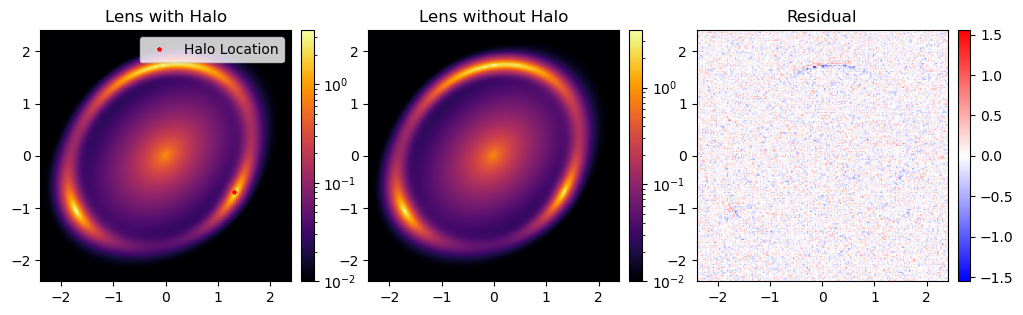

In [28]:
# img = sim_lens
dx = sim_config.delta_pix
n = sim_config.num_pix
dim = dx*n
extent = [-dim/2, dim/2, -dim/2, dim/2,]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_size_inches(12, 4)
# cnorm = matplotlib.colors.LogNorm(vmin=max(img.min(), 1e0), vmax=img.max(), clip=True)
# cmap = 'inferno'
# ax.imshow(img, extent=extent)#,cmap=cmap, norm=cnorm)
plot_image(fig, ax1, sim_lens, extent=extent, remove_axis=False, title="Lens with Halo")
plot_image(fig, ax2, sim_lens_no_halo, extent=extent, remove_axis=False, title="Lens without Halo")
plot_image(fig, ax3, sim_lens_noised-sim_lens_no_halo, extent=extent, remove_axis=False, title="Residual", residual=True)
# add_caustics(ax, true_params, sim_config, lens_objects=['EPL', 'TNFW_ELLIPSE_POTENTIAL', 'SHEAR'])
ax1.plot(halo_x, halo_y, "r*", markersize=3, label="Halo Location")
# ax.set_title(f"Lensing system halo added")
ax1.legend()
plt.show()

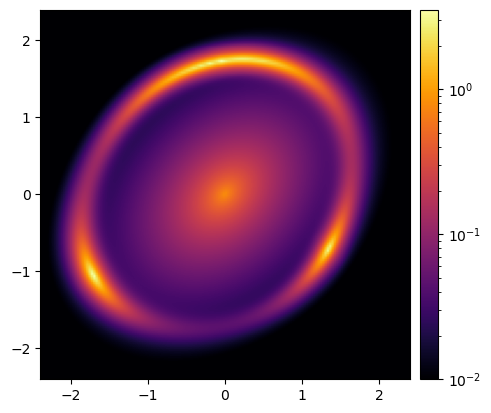

In [11]:
# img = sim_lens
dx = sim_config.delta_pix
n = sim_config.num_pix
dim = dx*n
extent = [-dim/2, dim/2, -dim/2, dim/2,]
fig, ax = plt.gcf(), plt.gca()
# cnorm = matplotlib.colors.LogNorm(vmin=max(img.min(), 1e0), vmax=img.max(), clip=True)
# cmap = 'inferno'
# ax.imshow(img, extent=extent)#,cmap=cmap, norm=cnorm)
plot_image(fig, ax, sim_lens, extent=extent, remove_axis=False)
# add_caustics(ax, true_params, sim_config, lens_objects=['EPL', 'TNFW_ELLIPSE_POTENTIAL', 'SHEAR'])
# ax.plot(halo_x, halo_y, "r*", markersize=3, label="Halo Location")
# ax.set_title(f"Lensing system halo added")
# ax.legend()
plt.show()

In [84]:
import gigalens
importlib.reload(gigalens.jax.profiles.mass.tnfw_ellipse)
from gigalens.jax.profiles.mass import tnfw_ellipse

In [87]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.25), 0.4),
                gamma=tfd.TruncatedNormal(2, 0.5, 1, 3),
                e1=tfd.Normal(0, 0.2),
                e2=tfd.Normal(0, 0.2),
                center_x=tfd.Normal(0, 0.06),
                center_y=tfd.Normal(0, 0.06),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                Rs=tfd.LogNormal(jnp.log(Rs_angle), 1.0),
                alpha_Rs=tfd.LogNormal(jnp.log(alpha_Rs), 1.0),
                r_trunc=tfd.Normal(100.0, 1.0),
                e1=tfd.Normal(0, 0.2),
                e2=tfd.Normal(0, 0.2),
                center_x=tfd.Normal(halo_x, 0.4),
                center_y=tfd.Normal(halo_y, 0.4),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.1), gamma2=tfd.Normal(0, 0.1))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.6), 0.25),
                n_sersic=tfd.Uniform(0.5, 8),
                e1=tfd.TruncatedNormal(0, 0.1, -0.15, 0.15),
                e2=tfd.TruncatedNormal(0, 0.1, -0.15, 0.15),
                center_x=tfd.Normal(0, 0.02),
                center_y=tfd.Normal(0, 0.02),
                Ie=tfd.LogNormal(jnp.log(300.0), 0.5),
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.25),
                n_sersic=tfd.Uniform(0.5, 8),
                e1=tfd.TruncatedNormal(0, 0.3, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.3, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.5),
                center_y=tfd.Normal(0, 0.5),
                Ie=tfd.LogNormal(jnp.log(150.0), 0.9),
            )
        )
    ]
)

prior_with_halo = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

phys_model_halo = PhysicalModel([epl.EPL(50), tnfw_ellipse.TNFW_Ellipse(), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
lens_sim_halo = LensSimulator(phys_model_halo, sim_config, bs=1)

observed_img = jnp.load(os.path.join(save_dir, "lens_img_no_halo.npy"))
prob_model_halo = ForwardProbModel(prior_with_halo, observed_img, background_rms=0.2, exp_time=100)
model_seq_halo = ModellingSequence(phys_model_halo, prob_model_halo, sim_config)

In [89]:
pipelinecfg = PipelineConfig(steps=["MAP", "SVI"],map_kwargs={"num_steps":500, "n_samples":1000}, )
results_halo = run_pipeline(model_seq_halo, pipelinecfg)

Starting MAP


Chi-squared: 1.016: 100%|██████████| 500/500 [00:40<00:00, 12.29it/s]


Final Chi-squared: 1.00620
Starting SVI


-ELBO: -4489.077: 100%|██████████| 500/500 [00:19<00:00, 25.05it/s]


In [90]:
qz = results_halo["SVI"].qz
best = results_halo["MAP"].best_z

In [105]:
from mclmc_alt import full_mclmc_with_adapt, init_multi, isokinetic_mclachlan_smart, MCLMCAdaptationState, mclmc_find_L_and_step_size_smart,mclachlan_coefficients

def log_prob(z):
    return prob_model_halo.log_prob(lens_sim_halo, z)[0]
qz = results_halo["SVI"].qz
inv_mass_mat = qz.covariance()

# inv_mass_mat_true = jnp.cov(hmc_samples.reshape(-1,hmc_samples.shape[-1]).T)

transform = lambda state, info: state.position


n_grad_per_integration_step_mclachlan = len(mclachlan_coefficients)//2 #* Happens on every odd step of the integrator

integrator = isokinetic_mclachlan_smart

 # build the kernel
kernel = lambda inverse_mass_matrix : blackjax.mcmc.mclmc.build_kernel(
    logdensity_fn=log_prob,
    integrator=integrator,
    inverse_mass_matrix=inverse_mass_matrix,
)


rng_key = jax.random.key(0)
init_key, tune_key, run_key = jax.random.split(rng_key, 3)

n_chains = 16
state_multi = init_multi(qz.sample((n_chains,), seed=init_key), init_key, log_prob)

starting_adapt_state = blackjax.adaptation.mclmc_adaptation.MCLMCAdaptationState(
    jnp.sqrt(dim), jnp.sqrt(dim) * 0.25, inverse_mass_matrix=inv_mass_mat
)

starttime = time.perf_counter()
mclmc_samples, params = full_mclmc_with_adapt(
    kernel=kernel,
    num_burnin_steps=10000,
    num_results=10000,
    state_init=state_multi,
    params_init=starting_adapt_state,
    rng_key=tune_key,
    frac_tune1=0.2, #* initial step size tuning
    frac_tune2=0.6, #* Used for mass matrix adaptation
    frac_tune3=0.2, #! Tuning L. ~10 effective samples are needed for this to be accurate
    desired_energy_var=10e-0,#desired_energy_variance,
    num_chains=n_chains,
    num_effective_samples=150,
    svi_mass_matrix_weight=10.0 * n_chains
)
jnp.save(os.path.join(save_dir, "mclmc_samples_halo_model_no_halo"), mclmc_samples)
total_time = time.perf_counter()-starttime
print(f"Sampling took {total_time} s")

Sampling took 174.052949799996 s


In [106]:
params.step_size

Array([0.22421865, 0.22421865, 0.22421865, 0.22421865, 0.22421865,
       0.22421865, 0.22421865, 0.22421865, 0.22421865, 0.22421865,
       0.22421865, 0.22421865, 0.22421865, 0.22421865, 0.22421865,
       0.22421865], dtype=float32, weak_type=True)

1.008442
[3018.379  2315.2312 2478.9912 1838.5952 1887.078  1332.2584 2109.5396
 1282.6556 2952.0479 3187.6938 2264.3662 2389.845  2913.8584 2615.8296
 1897.9308 3248.0618 3282.0142 2838.8982 2800.5422 2924.2852 3776.7822
 2418.6614 2791.5579 2179.8694 1931.6351 2392.1357 2787.825  2818.6091
 2729.0764]


KeyError: 'mass_1r_trunc'

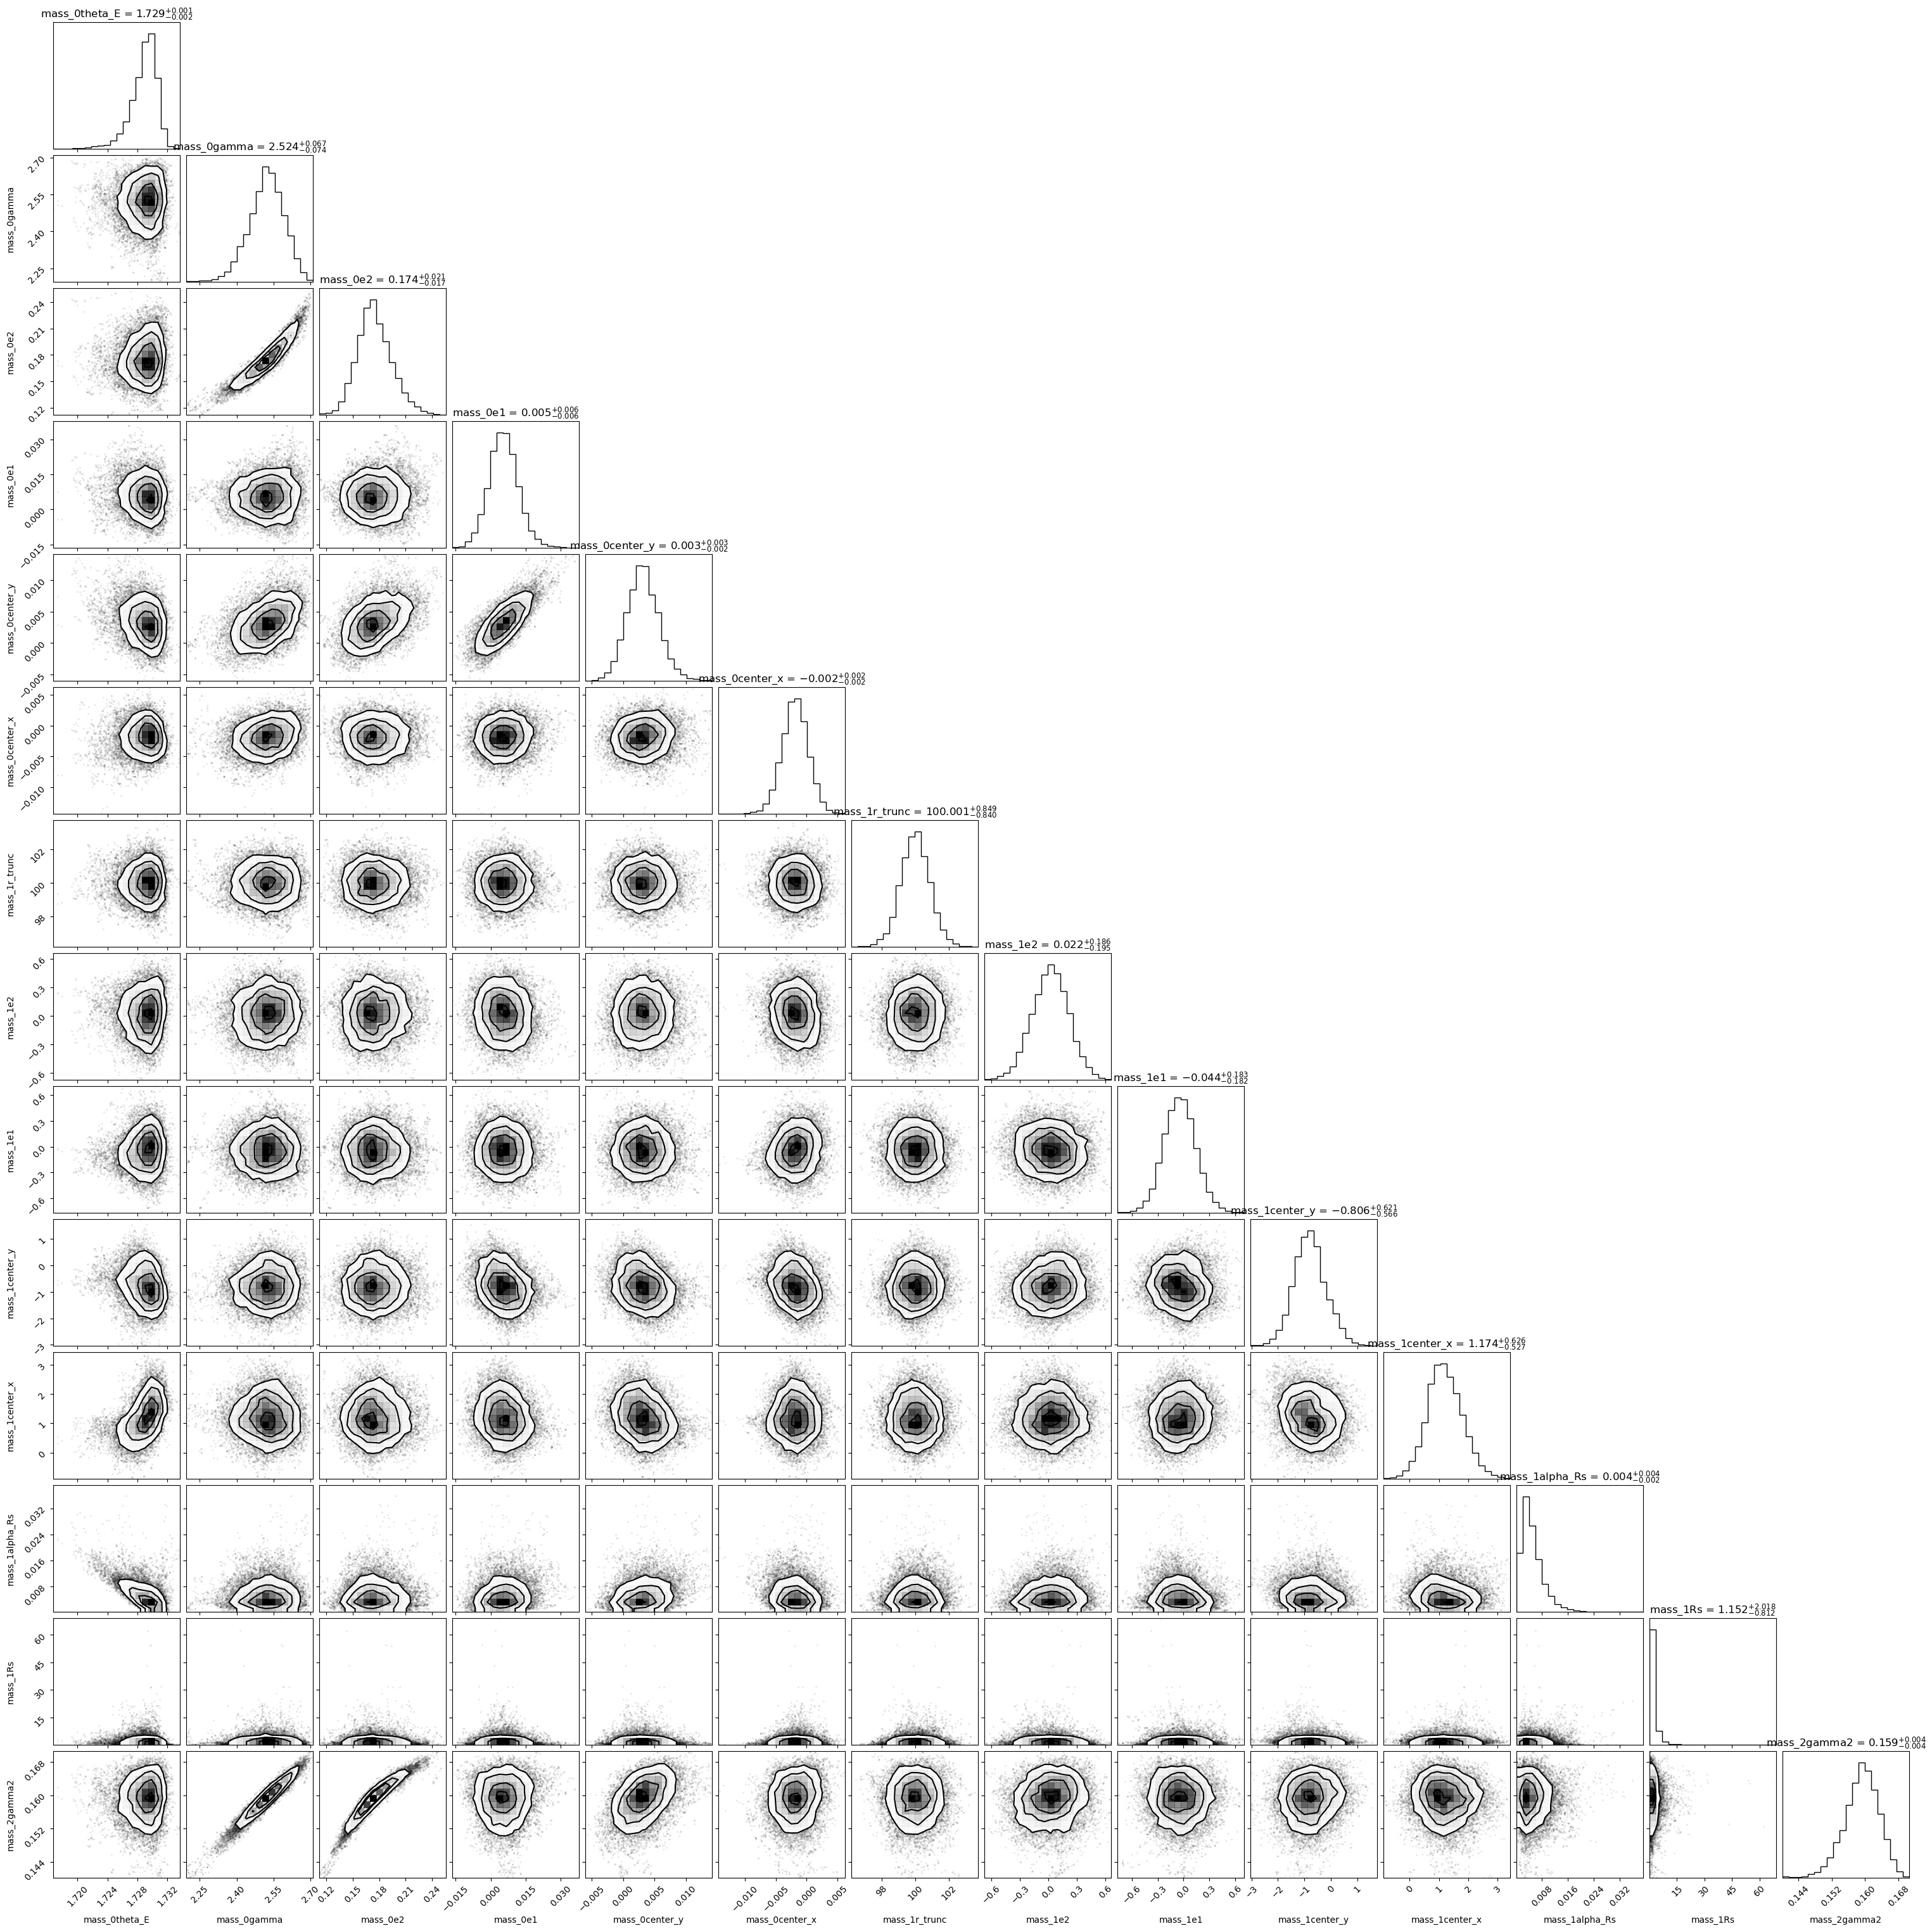

In [107]:
print(jnp.max(blackjax.diagnostics.potential_scale_reduction(mclmc_samples, chain_axis=0, sample_axis=1)))
print(blackjax.diagnostics.effective_sample_size(mclmc_samples, chain_axis=0, sample_axis=1))
dim=mclmc_samples.shape[-1]
run_key = jax.random.key(0)
samples = mclmc_samples[:, :,:].reshape(-1, dim) #samples_mclmc 
MCMC_x = prob_model_halo.bij.forward(list(samples.T))

# adapt_cov = blackjax_mclmc_sampler_params.inverse_mass_matrix
# adapt_qz = tfd.MultivariateNormalFullCovariance(loc=jnp.mean(samples, axis=0), covariance_matrix=adapt_cov)
# adapt_qz_samples = adapt_qz.sample((10000,), run_key)
# adapt_qz_x = prob_model.bij.forward(list(adapt_qz_samples.T))

SVI_samples = qz.sample((1000,), run_key)
SVI_x = prob_model_halo.bij.forward(list(SVI_samples.T))

MAP_x = prob_model_halo.bij.forward(list(best.T))

# HMC_1chain_x = prob_model.bij.forward(list(results['HMC'].HMC_samples_z[0, 11, -40000:].T))

plot_params = cornerplot_labels(MCMC_x)[:14]

# hmc_x = prob_model.bij.forward(list(hmc_samples.reshape(-1, dim).T))

# n_samp = hmc_samples.shape[0]*hmc_samples.shape[1]
# rand_idx = np.random.choice(np.arange(n_samp), size=(10000,), replace=False)

# fig = cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx], hmc_x), color='black',plot_params=plot_params)

n_samp_MCMC = MCMC_x[0][0]['e1'].shape[0]
rand_idx_MCMC = np.random.choice(np.arange(n_samp_MCMC), size=(20000,), replace=True)
fig = cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx_MCMC], MCMC_x), color='black',plot_params=plot_params)


cornerplot_posterior(SVI_x, fig=fig, color='blue', plot_params=plot_params, overplots=MAP_x#, truth=true_params)
# cornerplot_posterior(adapt_qz_x, fig=fig, color='purple')
# cornerplot_posterior(mclmc_results_100sys.HMC_samples, fig=fig, color='purple', plot_params=plot_params)
# cornerplot_posterior(HMC_1chain_x, fig=fig, color='green', plot_params=plot_params)

plt.show()

In [108]:
prior_no_halo = make_default_prior()

# observed_img = np.load(gigal_dir + '/assets/demo.npy')
phys_model_no_halo = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
lens_sim_no_halo = LensSimulator(phys_model_no_halo, sim_config, bs=1)

observed_img = jnp.load(os.path.join(save_dir, "lens_img_no_halo.npy"))
prob_model_no_halo = ForwardProbModel(prior_no_halo, observed_img, background_rms=0.2, exp_time=100)
model_seq_no_halo = ModellingSequence(phys_model_no_halo, prob_model_no_halo, sim_config)

In [109]:
pipelinecfg = PipelineConfig(steps=["MAP", "SVI"],map_kwargs={"num_steps":500}, )
results_no_halo = run_pipeline(model_seq_no_halo, pipelinecfg)

Starting MAP


Chi-squared: 1.013: 100%|██████████| 500/500 [00:23<00:00, 21.56it/s]


Final Chi-squared: 1.00642
Starting SVI


-ELBO: -4528.065: 100%|██████████| 500/500 [00:16<00:00, 30.12it/s]


In [110]:
from mclmc_alt import full_mclmc_with_adapt, init_multi, isokinetic_mclachlan_smart, MCLMCAdaptationState, mclmc_find_L_and_step_size_smart,mclachlan_coefficients

def log_prob(z):
    return prob_model_no_halo.log_prob(lens_sim_no_halo, z)[0]
qz = results_no_halo["SVI"].qz
inv_mass_mat = qz.covariance()

# inv_mass_mat_true = jnp.cov(hmc_samples.reshape(-1,hmc_samples.shape[-1]).T)

transform = lambda state, info: state.position


n_grad_per_integration_step_mclachlan = len(mclachlan_coefficients)//2 #* Happens on every odd step of the integrator

integrator = isokinetic_mclachlan_smart

 # build the kernel
kernel = lambda inverse_mass_matrix : blackjax.mcmc.mclmc.build_kernel(
    logdensity_fn=log_prob,
    integrator=integrator,
    inverse_mass_matrix=inverse_mass_matrix,
)

desired_energy_variance= 5e-4

rng_key = jax.random.key(0)
init_key, tune_key, run_key = jax.random.split(rng_key, 3)

n_chains = 16
state_multi = init_multi(qz.sample((n_chains,), seed=init_key), init_key, log_prob)

starting_adapt_state = blackjax.adaptation.mclmc_adaptation.MCLMCAdaptationState(
    jnp.sqrt(dim), jnp.sqrt(dim) * 0.25, inverse_mass_matrix=inv_mass_mat
)

starttime = time.perf_counter()
mclmc_samples, params = full_mclmc_with_adapt(
    kernel=kernel,
    num_burnin_steps=2000,
    num_results=2000,
    state_init=state_multi,
    params_init=starting_adapt_state,
    rng_key=tune_key,
    frac_tune1=0.2, #* initial step size tuning
    frac_tune2=0.6, #* Used for mass matrix adaptation
    frac_tune3=0.2, #! Tuning L. ~10 effective samples are needed for this to be accurate
    desired_energy_var=5e-4,#desired_energy_variance,
    num_chains=n_chains,
    num_effective_samples=150,
    svi_mass_matrix_weight=10.0 * n_chains
)
total_time = time.perf_counter()-starttime
print(f"Sampling took {total_time} s")
jnp.save(os.path.join(save_dir, "mclmc_samples_no_halo_no_halo"), mclmc_samples)

Sampling took 49.65642890399613 s


In [112]:
# results = {}
# results["MAP"] = MAPResults.load(os.path.join(home, "GIGALens-Code/alternate_inference/test_system"), model_seq)
# results["SVI"] = SVIResults.load(os.path.join(home, "GIGALens-Code/alternate_inference/test_system"), model_seq)
# results["HMC"] = HMCResults.load(os.path.join(home, "GIGALens-Code/alternate_inference/test_system"), model_seq)
# best = results["MAP"].best_z
# qz = results["SVI"].qz
# hmc_smp = jnp.transpose(results["HMC"].HMC_samples_z, (1, 2, 0, 3)).reshape((48, 750, 22))
mclmc_samples_no_halo = jnp.load(os.path.join(save_dir, "mclmc_samples_no_halo_no_halo.npy"))
mclmc_samples_halo = jnp.load(os.path.join(save_dir, "mclmc_samples_halo_model_no_halo.npy"))
print(jnp.max(blackjax.diagnostics.potential_scale_reduction(mclmc_samples_no_halo, chain_axis=0, sample_axis=1)))
print(jnp.max(blackjax.diagnostics.potential_scale_reduction(mclmc_samples_halo, chain_axis=0, sample_axis=1)))

1.005769
1.008442


In [22]:
nan_chain_idx = jnp.unique(jnp.where(jnp.isnan(mclmc_samples))[0])[4]
nan_chain = mclmc_samples[nan_chain_idx]
nan_step1 = jnp.unique(jnp.where(jnp.isnan(nan_chain))[0])[0]

log_prob = lambda z : prob_model_halo.log_prob(lens_sim_halo, z)[0]
pre_post_nan_step = nan_chain[nan_step1-2:nan_step1+1]
# lp_mapped = jax.vmap(log_prob)
lp_and_grad_mapped = jax.vmap(jax.value_and_grad(log_prob))
print(pre_post_nan_step)
print(lp_and_grad_mapped(pre_post_nan_step))
nan_lp_point = nan_chain[nan_step1-1] #* Has finite positions but NaN log prob

IndexError: index is out of bounds for axis 0 with size 0

In [ ]:
nan_x = prob_model_halo.bij.forward(list(nan_lp_point.T))
nan_img = lens_sim_halo.simulate(nan_x)
posx, posy = nan_x[0][1]['center_x'], nan_x[0][1]['center_y']
plt.imshow(nan_img, extent=extent)
plt.plot(posx,posy, 'r*')
plt.plot(halo_x, halo_y, "y*")
plt.show()

In [113]:
importlib.reload(helpers)
from helpers import *

In [114]:

def bridge_sampler(rng_key, samples, log_posterior_fn, n_iter=500):
    """
    Estimates the log-marginal likelihood using the Meng-Wong bridge sampler.
    
    Args:
        rng_key: JAX random key.
        samples: MCMC samples of shape (n_samples, n_dim).
        log_posterior_fn: Function mapping (theta) -> log_posterior(theta).
        n_iter: Number of iterations for the Meng-Wong algorithm.
    """
    n_samples, n_dim = samples.shape
    
    # 1. Fit a Gaussian proposal to the MCMC samples
    mu = jnp.mean(samples, axis=0)
    cov = jnp.cov(samples, rowvar=False)
    proposal = tfd.MultivariateNormalFullCovariance(loc=mu, covariance_matrix=cov)
    
    # 2. Draw 'fake' samples from the proposal
    prop_key, _ = jax.random.split(rng_key)
    gen_samples = proposal.sample(n_samples, seed=prop_key)
    
    l1 = log_posterior_fn(samples)
    l2 = log_posterior_fn(gen_samples)
    
    
    q1 = proposal.log_prob(samples)
    q2 = proposal.log_prob(gen_samples)

    n_lp_dims = len(l1.shape)-1
    if n_lp_dims > 0:
        q1 = jnp.expand_dims(q1, axis=tuple(range(-n_lp_dims, 0)))
        q2 = jnp.expand_dims(q2, axis=tuple(range(-n_lp_dims, 0)))
    
    # 4. Iterative Meng-Wong Algorithm
    log_r_guess = jnp.log(1/n_samples) + jax.nn.logsumexp(l2-q2, axis=0)
    log_r = log_r_guess

    
    h = []
    s1 = 0.5 # Proportion of samples from posterior (assuming n1 == n2)
    s2 = 0.5 # Proportion of samples from proposal
    
    for _ in range(n_iter):
        l_num = l2 - jnp.logaddexp(jnp.log(s1) + l2, jnp.log(s2) + log_r + q2)
        
        l_den = q1 - jnp.logaddexp(jnp.log(s1) + l1, jnp.log(s2) + log_r + q1)
        
        # Update log_r
        log_r_new = jax.nn.logsumexp(l_num, axis=0) - jax.nn.logsumexp(l_den, axis=0)
        
        # For stability, we can track the delta or use a small dampening factor if needed
        log_r = log_r_new
        h.append(log_r)

    return log_r, jnp.stack(h)

def evidence_and_map(samples, prob_model, lens_sim):
    # log_prob_image_vmap = jax.vmap(lambda z : log_prob_image_patched(prob_model, lens_sim, z, kernel_size=1), in_axes=0)
    
    smp = samples.reshape((-1, samples.shape[-1]))
    idxes = jax.random.choice(jax.random.key(2), smp.shape[0], shape=(2000,))

    # log_r_img, h = bridge_sampler(jax.random.key(0), smp[idxes], log_prob_image_vmap)

    def log_prob(z):
        return prob_model.log_prob(lens_sim, z)[0]

    log_r,h = bridge_sampler(jax.random.key(1), smp[idxes], log_prob)

    return log_r, None

In [115]:
z_halo, z_map_halo = evidence_and_map(mclmc_samples_halo, prob_model_halo, lens_sim_halo)
z_no_halo, z_map_no_halo = evidence_and_map(mclmc_samples_no_halo, prob_model_no_halo, lens_sim_no_halo)


In [122]:
print(f"Halo Model Z:, {z_halo:.2f}. No-Halo Model Z: {z_no_halo:.2f}")
print(f"Halo is {jnp.exp(z_halo-z_no_halo):.2f}x (10^{(z_halo-z_no_halo)/jnp.log(10):.1f}) as likely")

Halo Model Z:, 4604.86. No-Halo Model Z: 4608.50
Halo is 0.03x (10^-1.6) as likely


In [117]:
import matplotlib

TypeError: Image data of dtype object cannot be converted to float

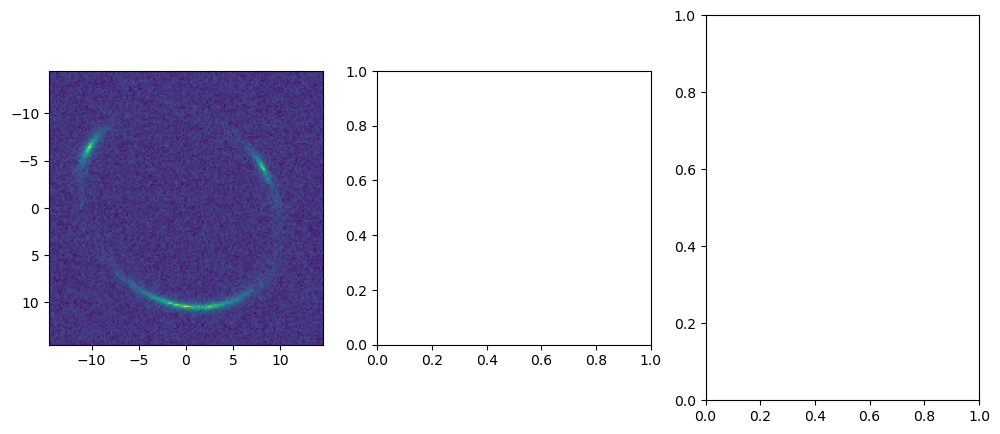

In [118]:
fig, (ax0, ax1,ax2) = plt.subplots(1,3)
fig.set_size_inches(12, 5)
extent = [-dim/2, dim/2, dim/2, -dim/2,]

halo_median = jnp.median(mclmc_samples_halo, axis=(0,1))
med_x = prob_model_halo.bij.forward(list(halo_median.T))
halox_pred, haloy_pred = med_x[0][1]['center_x'], med_x[0][1]['center_y']



ax0.imshow(observed_img, extent=extent)

# cnorm = matplotlib.colors.Normalize(vmin=min(jnp.min(z_map_halo), jnp.min(z_map_no_halo)), vmax=max(jnp.max(z_map_halo), jnp.max(z_map_no_halo)))
tr = lambda x : x#jnp.square(x-jnp.min(x))
im1 = ax1.imshow(tr(z_map_halo), extent=extent, cmap='plasma')#, norm=cnorm)
ax1.set_title("Halo Model Evidence Map")
# ax1.plot(halox_pred, haloy_pred, "g^", label="Pred Halo Location", markersize=3)
# ax1.plot(halo_x, halo_y, "k^", label="True Halo Location", markersize=3)
# ax1.legend()

im2 = ax2.imshow(tr(z_map_no_halo), extent=extent, cmap='plasma')#, norm=cnorm)
ax2.set_title("No-Halo Model Evidence Map")
# ax2.plot(halo_x, halo_y, "k^", label="True Halo Location", markersize=3)
# ax2.legend()

for ax in (ax0, ax1, ax2):
    ax.set_xlim((extent[0], extent[1]))
    ax.set_ylim((extent[2], extent[3]))

for ax, im in zip((ax1, ax2), (im1, im2)):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax)
    
plt.show()

1.6360398908022806


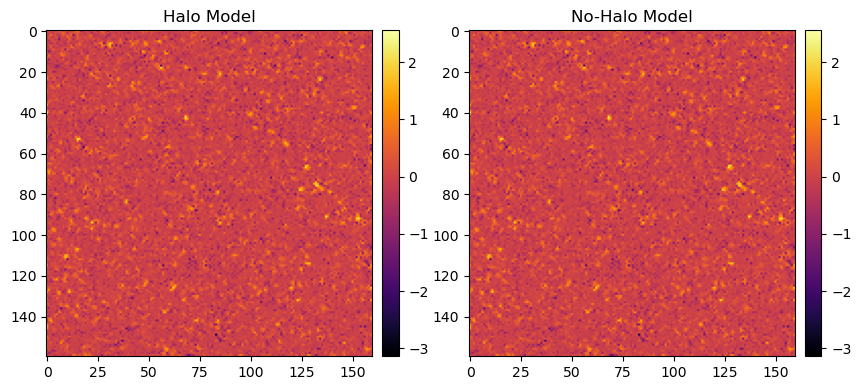

In [121]:
from scipy.ndimage import gaussian_filter, convolve

def compute_local_morans_i(residual_image):
    """
    Computes the Local Moran's I map for a 2D residual image.
    
    Positive values indicate clusters of similar values (correlated misfit).
    Negative values indicate spatial outliers.
    Values near zero indicate randomness (pure noise).
    """
    # 1. Standardize the image (z-scores)
    # If your residual is already perfectly N(0,1), this step is just a safeguard
    # z = (residual_image - np.mean(residual_image)) / np.std(residual_image)
    z = residual_image
    
    # 2. Define the spatial weights matrix (Moore neighborhood / 8-connected)
    # The center is 0 because a pixel shouldn't be correlated with itself
    # We divide by 8 to row-standardize the weights
    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]]) / 8.0

    # kernel = np.array([[0.5, 0.5, 0.5, 0.5, 0.5],
    #                    [0.5, 1, 1, 1, 0.5],
    #                    [0.5, 1, 0, 1, 0.5],
    #                    [0.5, 1, 1, 1, 0.5],
    #                    [0.5, 0.5, 0.5, 0.5, 0.5]])
    # kernel /= np.sum(kernel)

    # kernel = np.ones(shape=(5,5))
    # kernel[2,2]=0
    # kernel /= np.sum(kernel)

    
    # 3. Compute the spatial lag (weighted average of neighbors)
    # mode='reflect' handles the edges nicely
    z_lag = convolve(z, kernel, mode='reflect')
    
    # 4. Calculate Local Moran's I
    local_morans_i = z * z_lag
    
    return local_morans_i

halo_median = jnp.median(mclmc_samples_halo, axis=(0,1))
med_x_halo = prob_model_halo.bij.forward(list(halo_median.T))

no_halo_median = jnp.median(mclmc_samples_no_halo, axis=(0,1))
med_x_no_halo = prob_model_no_halo.bij.forward(list(no_halo_median.T))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(10, 5)

null_img = np.random.normal(size=observed_img.shape)
null_moran = compute_local_morans_i(null_img).flatten()
thresh = np.percentile(null_moran, 99.8)
print(thresh)

# cnorm = matplotlib.colors.Norm(vmin=0, v)
def chisq_map(ax, observed_image, lens_sim, pred_x,background_rms, exp_time):
    
    pred_img = lens_sim.simulate(pred_x)

    noise_map = get_noise_image(observed_image, background_rms, exp_time)

    
    cmap = 'inferno'

    residual = (observed_img - pred_img)/noise_map

    # kernel_size=6
    # window = jnp.ones((kernel_size, kernel_size))

    # show = jax.scipy.signal.convolve(jnp.square(residual)/(kernel_size**2), window, mode='full')
    # show = gaussian_filter(residual, sigma=3)

    show = compute_local_morans_i(residual)

    cnorm = matplotlib.colors.Normalize()
    # show = np.where(show< thresh, 0, show)
    
    im= ax.imshow(show, cmap=cmap, norm=cnorm)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax)

chisq_map(ax1, observed_img, lens_sim_halo, med_x_halo,background_rms = 0.2, exp_time = 100.)
ax1.set_title("Halo Model")
chisq_map(ax2, observed_img, lens_sim_no_halo, med_x_no_halo,background_rms = 0.2, exp_time = 100.)
ax2.set_title("No-Halo Model")



plt.show()

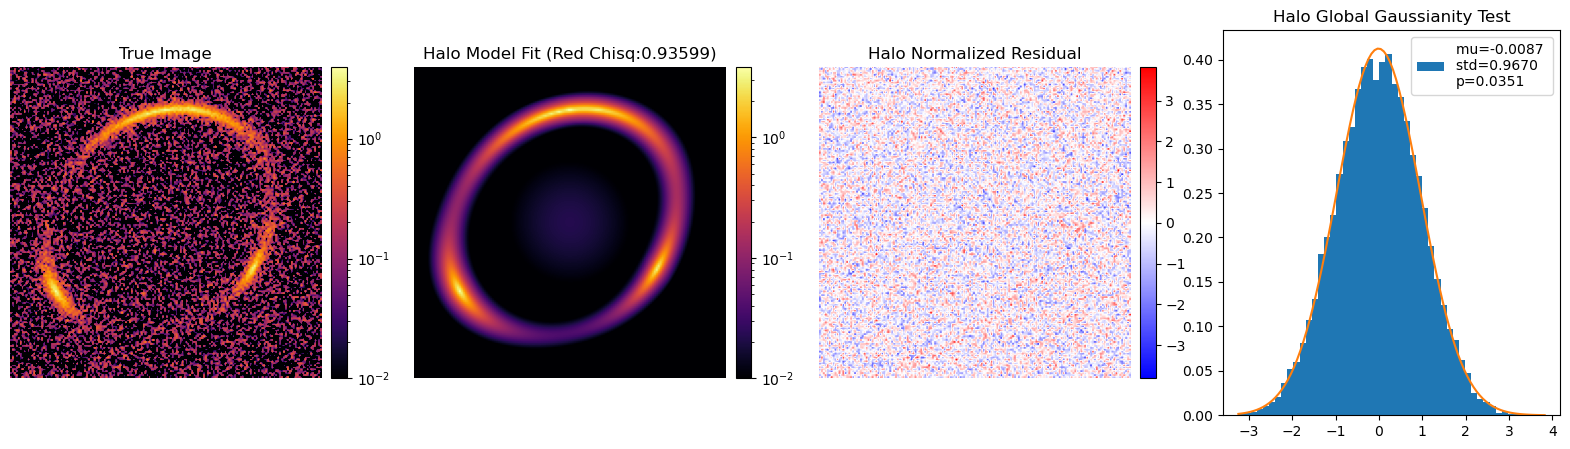

In [119]:
importlib.reload(helpers)
from helpers import *
fig, axs = plt.subplots(1,4)
fig.set_size_inches(20,5)

plot_image_results(fig, axs, jnp.array(observed_img), prefix="Halo", lens_sim=lens_sim_halo, predicted_params=med_x, background_rms = 0.2, exp_time = 100.)
plt.show()

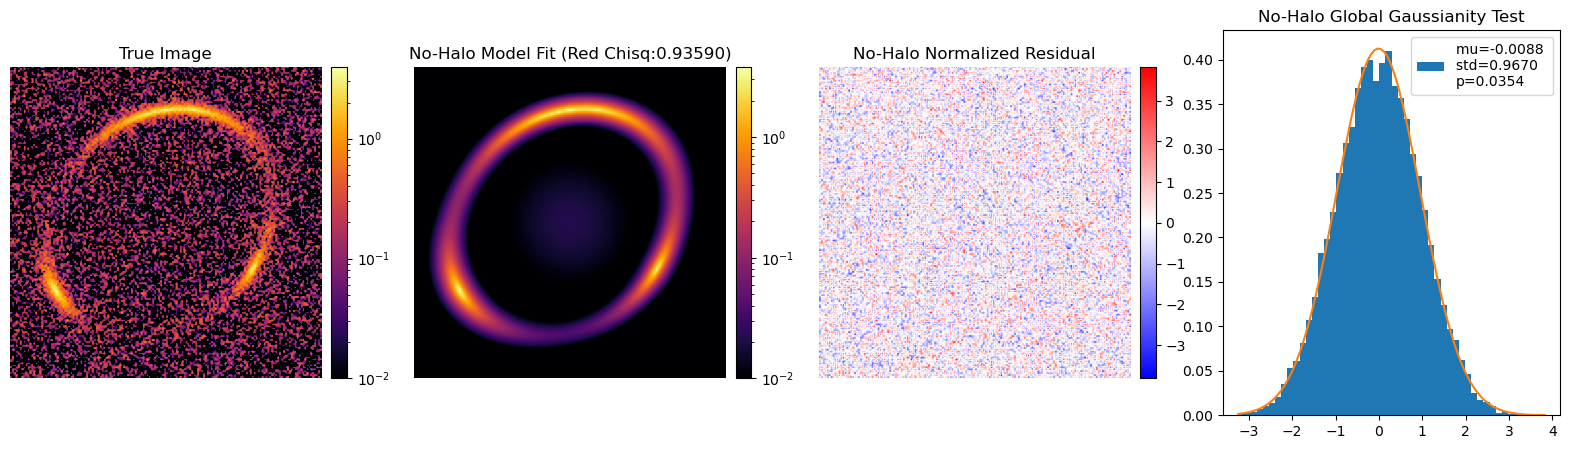

In [120]:
fig, axs = plt.subplots(1,4)
fig.set_size_inches(20,5)

no_halo_median = jnp.median(mclmc_samples_no_halo, axis=(0,1))
med_x_no_halo = prob_model_no_halo.bij.forward(list(no_halo_median.T))
plot_image_results(fig, axs, jnp.array(observed_img), prefix="No-Halo", lens_sim=lens_sim_no_halo, predicted_params=med_x_no_halo, background_rms = 0.2, exp_time = 100.)
plt.show()